<a href="https://colab.research.google.com/github/mdatherahmad/helmet-detection-yolov5s/blob/main/yolov8_train.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
!nvidia-smi

Mon May  4 19:11:32 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   41C    P8              9W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [3]:

import os
HOME = os.getcwd()
print(HOME)


/content


In [6]:
!pip install ultralytics

In [7]:
from IPython import display
display.clear_output()

import ultralytics
ultralytics.checks()

Ultralytics 8.4.46 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
Setup complete ✅ (2 CPUs, 12.7 GB RAM, 43.1/112.6 GB disk)


In [8]:

from ultralytics import YOLO

from IPython.display import display, Image

In [9]:
%cd /content
!curl -L "https://github.com/mdatherahmad/helmet-detection-yolov5s/raw/refs/heads/main/helmet.v1i.yolov5pytorch.zip" >dataset.zip; unzip dataset.zip; rm dataset.zip

/content
  % Total    % Received % Xferd  Average Speed   Time    Time     Time  Current
                                 Dload  Upload   Total   Spent    Left  Speed
  0     0    0     0    0     0      0      0 --:--:-- --:--:-- --:--:--     0
100 18.2M  100 18.2M    0     0  9923k      0  0:00:01  0:00:01 --:--:-- 63.1M
Archive:  dataset.zip
 extracting: test/images/helm_000096_jpg.rf.ac42b410a46ac869abd020ba348ed93d.jpg  
 extracting: test/images/helm_000143_jpg.rf.b35d9f5489590e578ac90c24ddd9bff0.jpg  
 extracting: test/images/helm_000132_jpg.rf.16c4fd835659fca98342f1a2f0024af0.jpg  
 extracting: test/images/helm_000094_jpg.rf.cc8ba48c5e07b8236b9ef83da3d0121d.jpg  
 extracting: test/images/helm_000150_jpg.rf.edfa839078c671a2d59198e59fafe7e3.jpg  
 extracting: test/images/helm_001671_jpg.rf.2f84d951265ad2861990cd172c33a622.jpg  
 extracting: train/images/helm_000042_jpg.rf.a81c7d4f23a402ae7e8f255007ee5fc1.jpg  
 extracting: test/images/helm_001565_jpg.rf.b709b13a484501aa67a6e15647e

In [10]:
%cat data.yaml

train: ../train/images
val: ../valid/images
test: ../test/images

nc: 1
names: ['helmet']

roboflow:
  workspace: athers-workspace
  project: helmet-kmhor
  version: 1
  license: CC BY 4.0
  url: https://universe.roboflow.com/athers-workspace/helmet-kmhor/dataset/1

In [11]:
!yolo task=detect mode=train model=yolov8s.pt data= data.yaml epochs=25 imgsz=224 plots=True


Ultralytics 8.4.46 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=data.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=25, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=224, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8s.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=train, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_mask=True, patience=100, perspective=0.0, pl

In [15]:


!ls runs/detect/train/

args.yaml			 labels.jpg	     train_batch1.jpg
BoxF1_curve.png			 results.csv	     train_batch2.jpg
BoxP_curve.png			 results.png	     val_batch0_labels.jpg
BoxPR_curve.png			 train_batch0.jpg    val_batch0_pred.jpg
BoxR_curve.png			 train_batch165.jpg  weights
confusion_matrix_normalized.png  train_batch166.jpg
confusion_matrix.png		 train_batch167.jpg


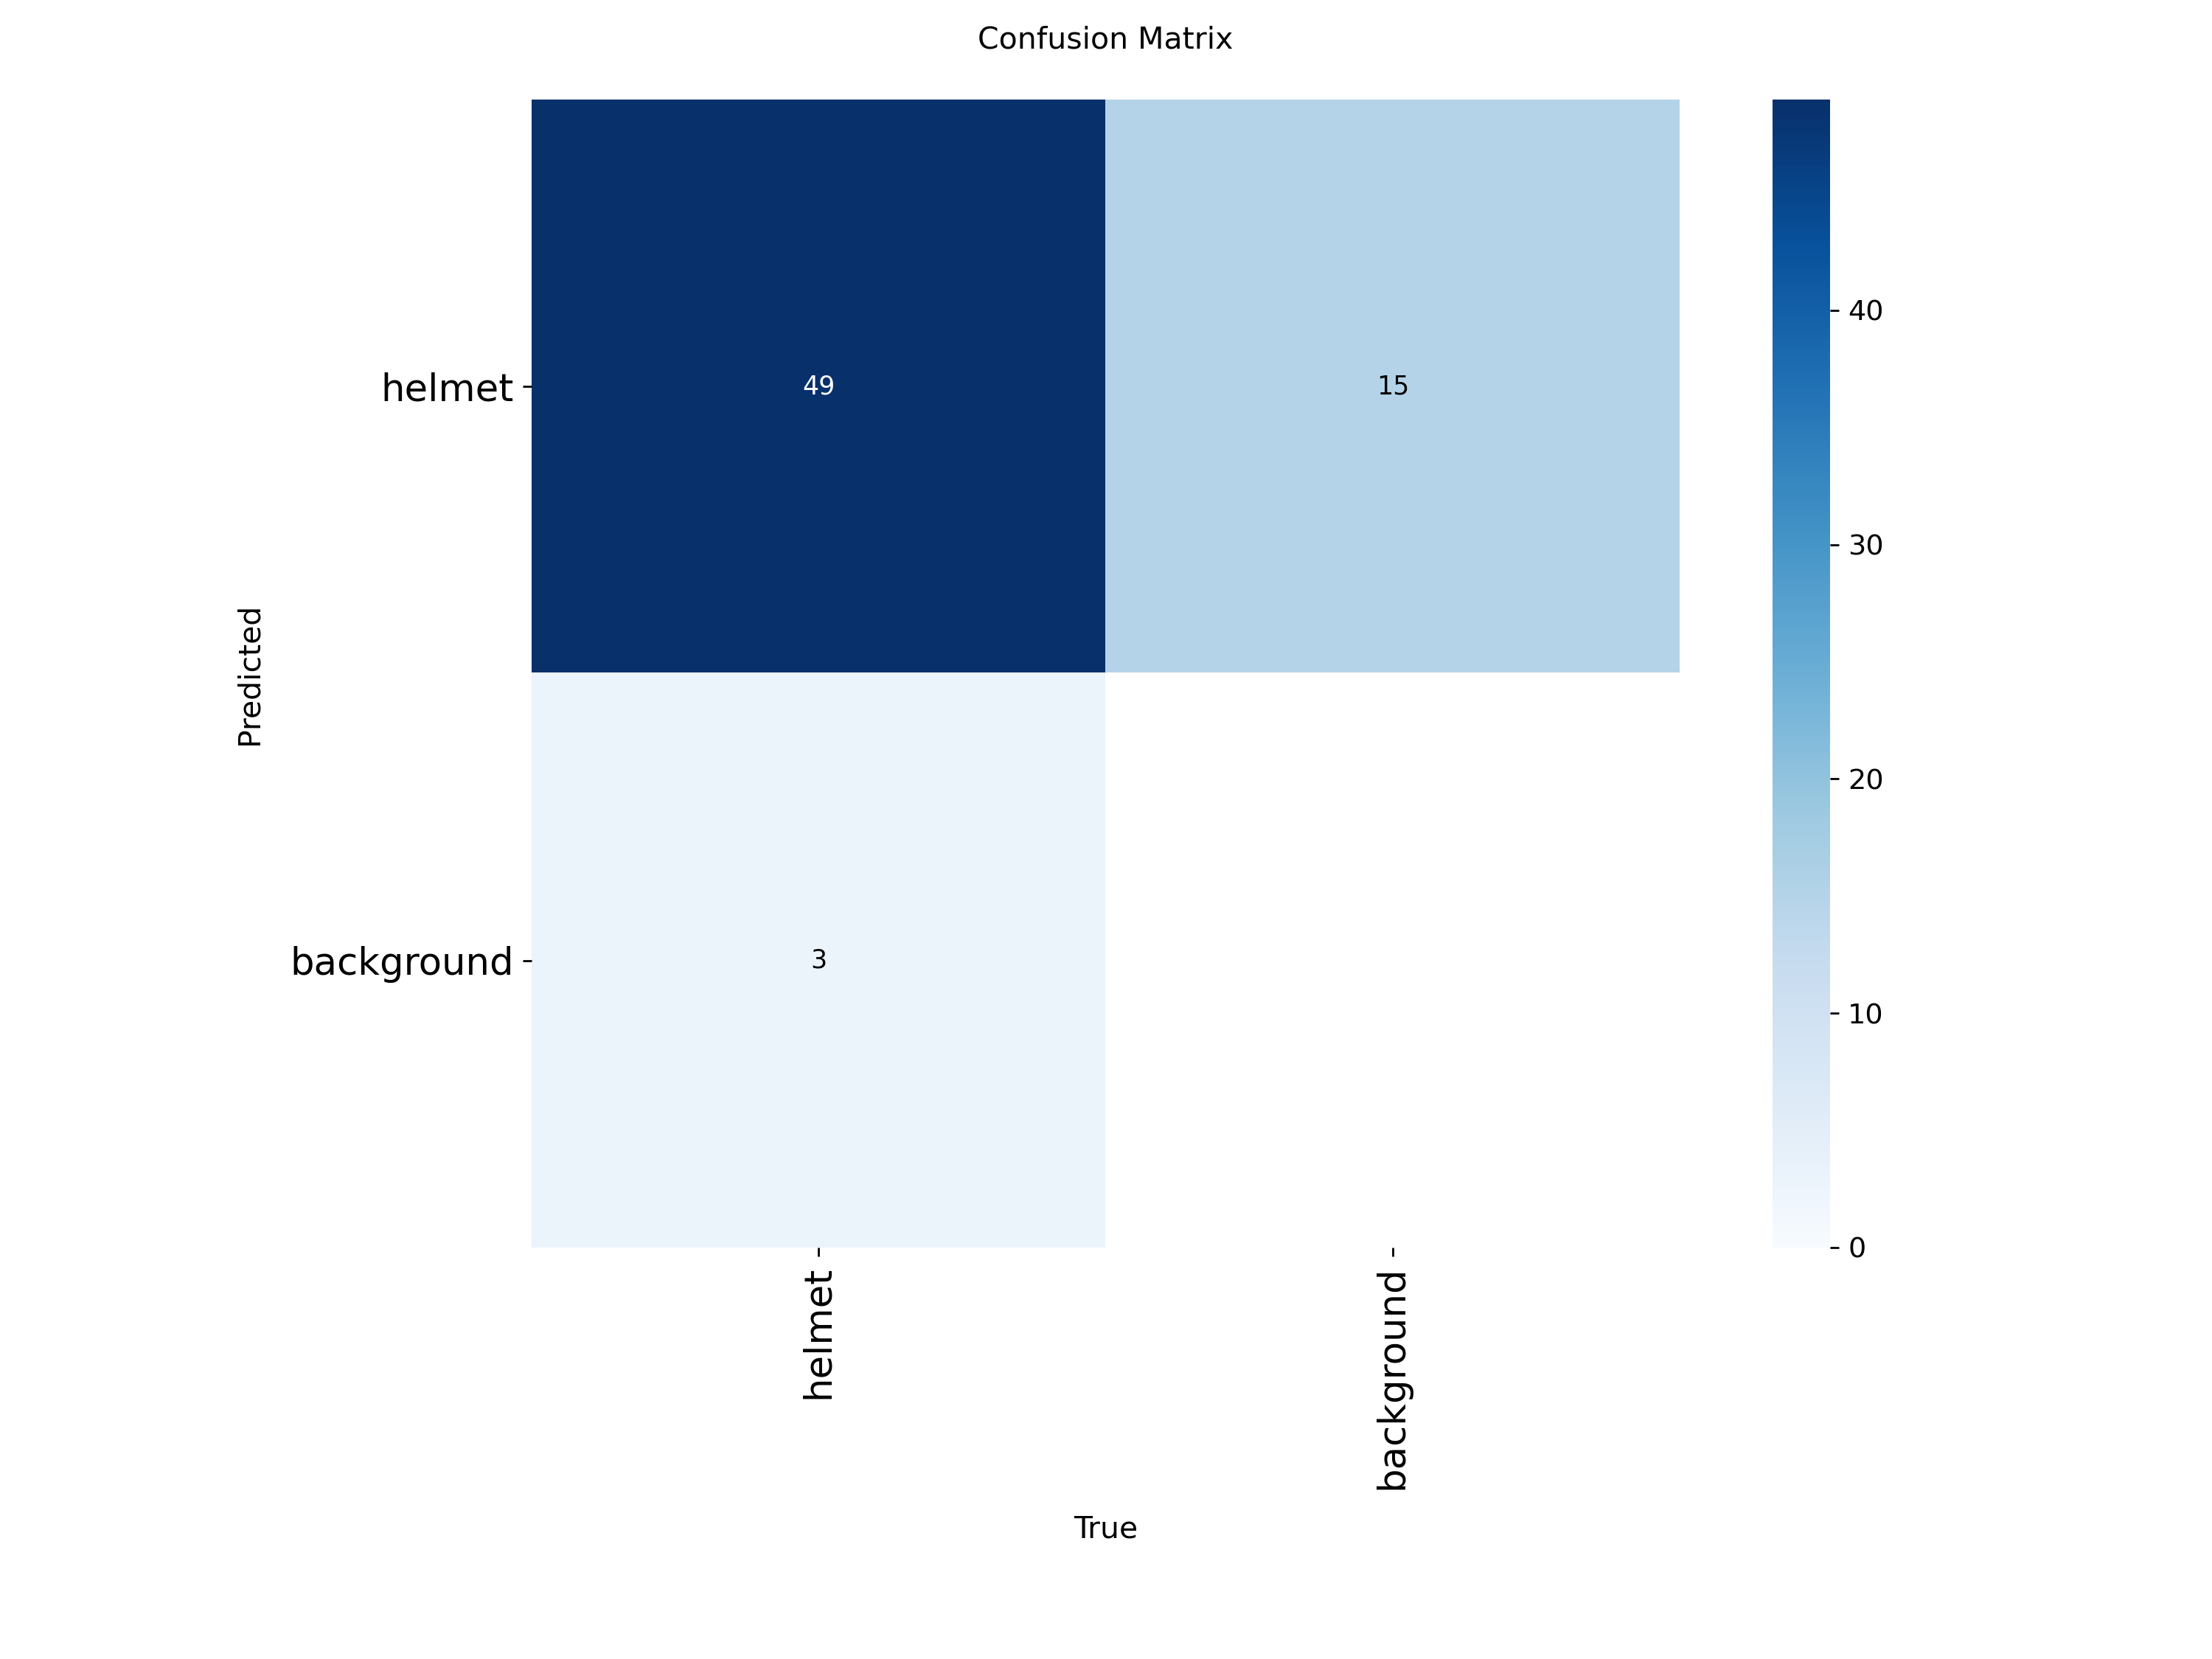

In [17]:

Image(filename='runs/detect/train/confusion_matrix.png', width=600)

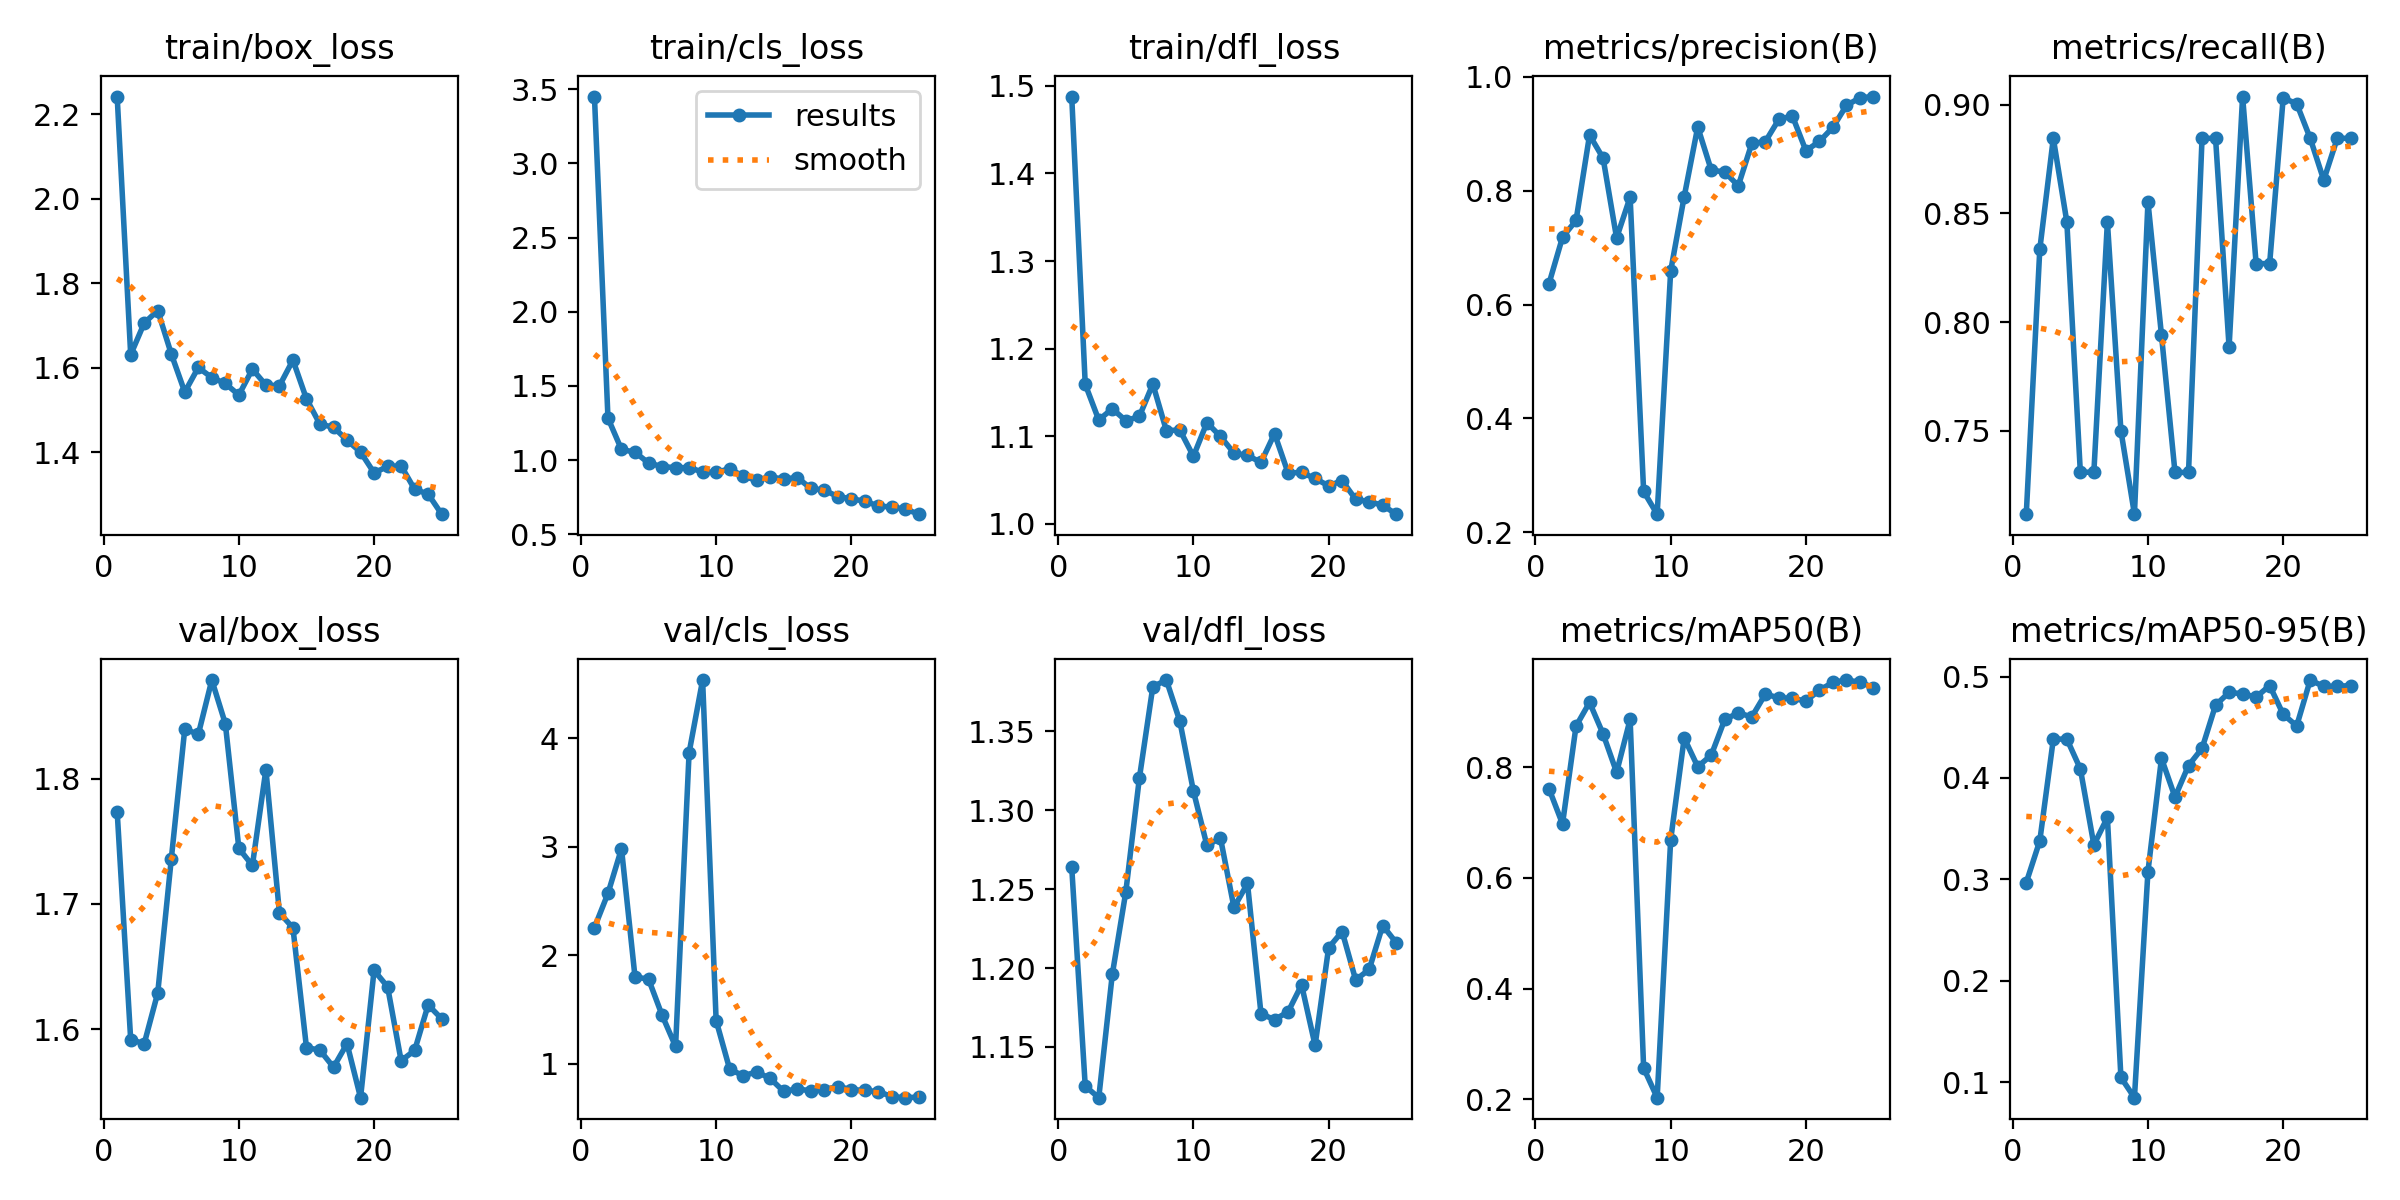

In [19]:

Image(filename='runs/detect/train/results.png', width=600)

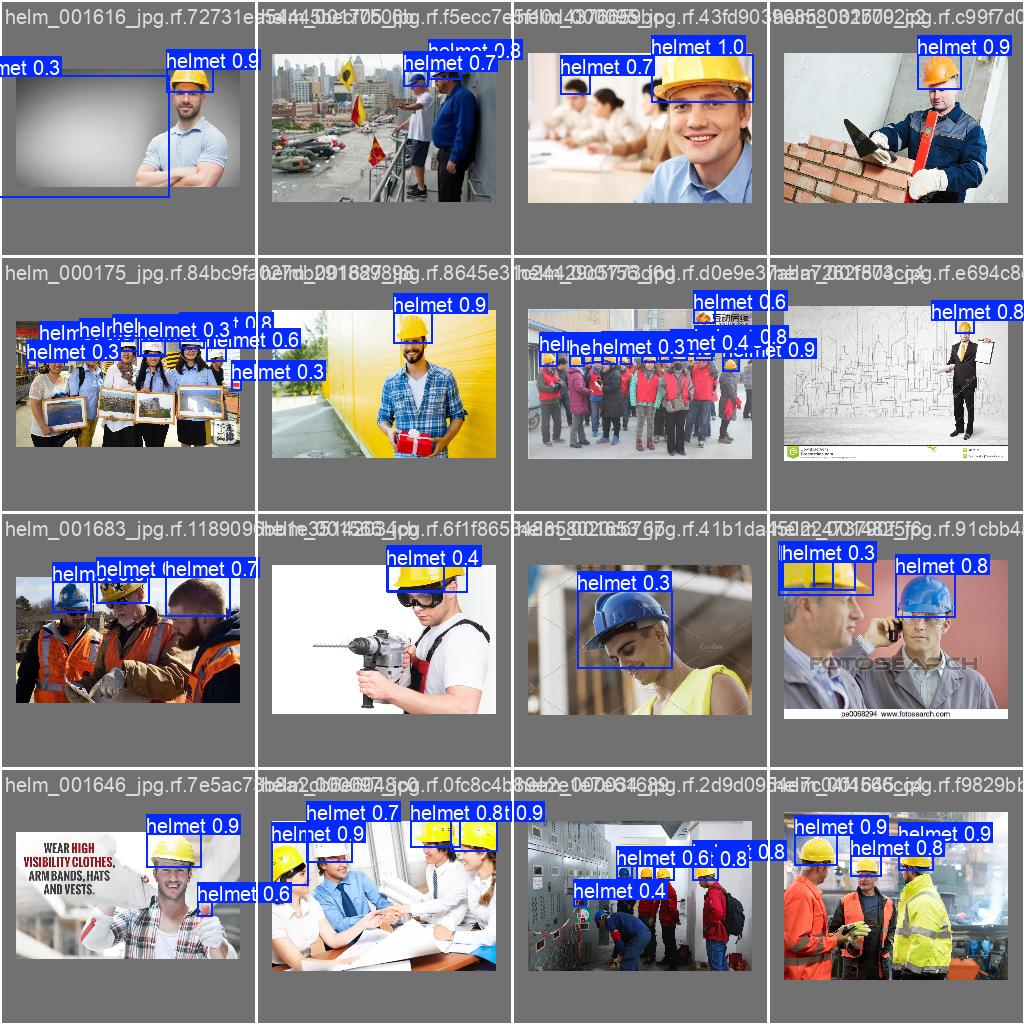

In [21]:

Image(filename='runs/detect/train/val_batch0_pred.jpg', width=600)